In [18]:

import numpy as np                
import pandas as pd                
import matplotlib.pyplot as plt    
from pathlib import Path


from iminuit import Minuit

# Configurazione grafica 
plt.rcParams.update({
    'font.family': 'serif',        
    'mathtext.fontset': 'cm',      
    'figure.figsize': (10, 6),      
    'axes.grid': True,             
    'grid.linestyle': '--',        
    'grid.alpha': 0.6,             
    'errorbar.capsize': 3,         
    'lines.linewidth': 1.5,        
    'lines.markersize': 5          
})

In [19]:
# CELLA 2: LETTURA DATI E CALCOLO INCERTEZZE
# Sostituisci col nome del tuo file
nome_file = 'EsempioDati.csv'

try:
    df = pd.read_csv(nome_file, sep=';', decimal=',')
    # Rimuove le righe dove manca anche un solo dato per non disallineare gli array!
    df = df.dropna() 
    
    # Estrazione dati 
    x = df['x'].to_numpy(dtype=float)       # Posizione indice sul binario [mm]
    V_R = df['V_R'].to_numpy(dtype=float)   # Tensione a luce diretta [V]
    V_F = df['V_F'].to_numpy(dtype=float)   # Tensione di fondo [V]

    # Calcolo del segnale utile
    V = V_R - V_F

    # Assegnazione degli errori 
    # Errore su x: uniforme, larghezza tacca ~ 0.2 mm
    err_x = np.full_like(x, 0.2 / np.sqrt(12)) 
    
    # Errore su V: errore del multimetro + fluttuazione fondo (da valutare in lab, qui metto valori di stima)
    err_lettura = 0.01  # es. 10 mV
    err_fondo = 0.005   # es. 5 mV 
    err_V = np.full_like(V, np.sqrt(err_lettura**2 + err_fondo**2))

    print(f"Letti  {len(x)} punti.")

except FileNotFoundError:
    print(f"File {nome_file} non trovato.")
    

Letti  4 punti.



--- ESECUZIONE FIT 3 PARAMETRI ---
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.526e+04                  │              Nfcn = 270              │
│ EDM = 5.04e-08 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬───

<>:44: SyntaxWarning: invalid escape sequence '\c'
<>:45: SyntaxWarning: invalid escape sequence '\p'
<>:46: SyntaxWarning: invalid escape sequence '\p'
<>:47: SyntaxWarning: invalid escape sequence '\p'
<>:44: SyntaxWarning: invalid escape sequence '\c'
<>:45: SyntaxWarning: invalid escape sequence '\p'
<>:46: SyntaxWarning: invalid escape sequence '\p'
<>:47: SyntaxWarning: invalid escape sequence '\p'
/var/folders/s4/_bthznv52l9_j9tcmc5dxzkh0000gn/T/ipykernel_71948/4077118355.py:44: SyntaxWarning: invalid escape sequence '\c'
  res_testo = (f"$\chi^2/ndof$ = {chi2_3:.2f} / {ndof_3}\n"
/var/folders/s4/_bthznv52l9_j9tcmc5dxzkh0000gn/T/ipykernel_71948/4077118355.py:45: SyntaxWarning: invalid escape sequence '\p'
  f"$A$ = {A_fit:.1f} $\pm$ {err_A:.1f}\n"
/var/folders/s4/_bthznv52l9_j9tcmc5dxzkh0000gn/T/ipykernel_71948/4077118355.py:46: SyntaxWarning: invalid escape sequence '\p'
  f"$B$ = {B_fit:.2f} $\pm$ {err_B:.2f} mm\n"
/var/folders/s4/_bthznv52l9_j9tcmc5dxzkh0000gn/T/ipykernel_719

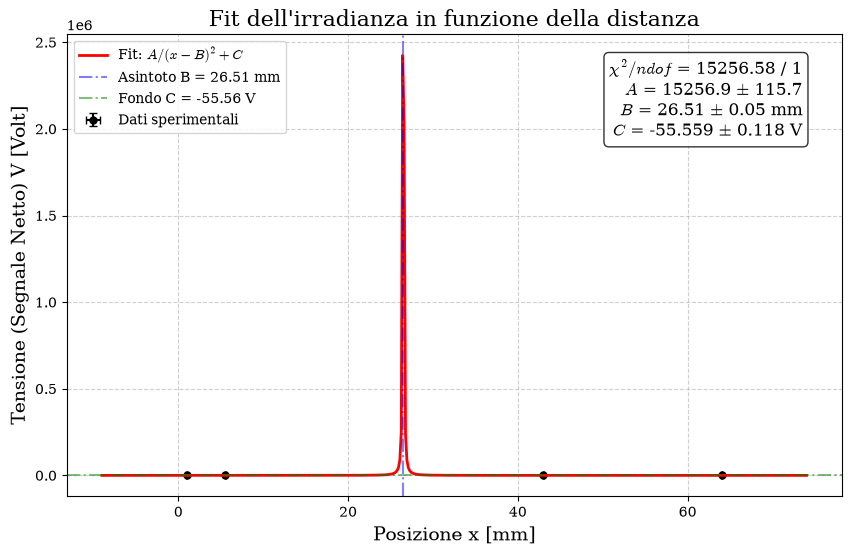

In [20]:
# FIT A 3 PARAMETRI (A, B, C)

# Definizione del modello: f(x) = A / (x - B)^2 + C
def f3(x, A, B, C):
    return A / (x - B)**2 + C

# Derivata analitica di f(x) rispetto ad x (serve per la varianza efficace)
def df3(x, A, B, C):
    return -2 * A / (x - B)**3

# Funzione da minimizzare: Chi Quadrato con varianza efficace
def chi2_eff_3(A, B, C):
    # Propagazione dell'errore di x sulle ordinate
    sigma_eff = np.sqrt(err_V**2 + (err_x * df3(x, A, B, C))**2)
    return np.sum(((V - f3(x, A, B, C)) / sigma_eff)**2)

print("\n--- ESECUZIONE FIT 3 PARAMETRI ---")
# Parametri iniziali (guess). Aggiustali se il fit non converge!
m3 = Minuit(chi2_eff_3, A=5000, B=10, C=0.1)
m3.errordef = Minuit.LEAST_SQUARES
m3.migrad()
m3.hesse()

# Estrazione Risultati
A_fit, B_fit, C_fit = m3.values["A"], m3.values["B"], m3.values["C"]
err_A, err_B, err_C = m3.errors["A"], m3.errors["B"], m3.errors["C"]
chi2_3 = m3.fval
ndof_3 = len(x) - 3

print(m3)

# PLOT DEL FIT
plt.figure()
plt.errorbar(x, V, xerr=err_x, yerr=err_V, fmt='ko', label='Dati sperimentali', zorder=1)

x_plot = np.linspace(min(x)-10, max(x)+10, 500)
plt.plot(x_plot, f3(x_plot, A_fit, B_fit, C_fit), 'r-', lw=2, label='Fit: $A/(x-B)^2 + C$', zorder=2)

# Asintoti B e C
plt.axvline(B_fit, color='blue', linestyle='-.', alpha=0.5, label=f'Asintoto B = {B_fit:.2f} mm')
plt.axhline(C_fit, color='green', linestyle='-.', alpha=0.5, label=f'Fondo C = {C_fit:.2f} V')

# Box di testo coi risultati
res_testo = (f"$\chi^2/ndof$ = {chi2_3:.2f} / {ndof_3}\n"
             f"$A$ = {A_fit:.1f} $\pm$ {err_A:.1f}\n"
             f"$B$ = {B_fit:.2f} $\pm$ {err_B:.2f} mm\n"
             f"$C$ = {C_fit:.3f} $\pm$ {err_C:.3f} V")
plt.text(0.95, 0.95, res_testo, transform=plt.gca().transAxes, 
         fontsize=12, verticalalignment='top', horizontalalignment='right', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.xlabel('Posizione x [mm]', fontsize=14)
plt.ylabel('Tensione (Segnale Netto) V [Volt]', fontsize=14)
plt.title('Fit dell\'irradianza in funzione della distanza', fontsize=16)
plt.legend()
plt.show()